In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [32]:
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score

def metricas(y_true, y_pred):
    resultados = {}
    resultados['RMSE'] = rmse(y_true, y_pred)
    resultados['MAPE'] = mape(y_true, y_pred)
    resultados['R2'] = r2_score(y_true, y_pred)

    # Evitar división por cero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    error = (y_pred - y_true) / y_true

    resultados['Mediana_ErrorAbs'] = np.median(np.abs(error))
    resultados['Pct_Error<0.3'] = np.sum(np.abs(error) <= 0.3) / len(error)
    return resultados

In [4]:
train = pd.read_csv('datos_preprocesados_train_final_smote.csv', index_col=0)
df = pd.read_csv('datos_preprocesados_depurados_final.csv', index_col=0)

In [5]:
train.head()

,mts2,dormitorios,parqueos,banos,CANT_HOSPITAL,CANT_SUPERMERCADO,hogares_lectura,hogares_techo_lamina,hogares_sin_agua,miembros_ph_avg,...,DEPTO_le,DEPTO_avg,zona_le,zona_avg,nom_dpto_le,nom_dpto_avg,nom_mun_le,nom_mun_avg,precio,perfil
0,226.0,3.000000,3.000000,3.000000,28.0,13.0,0.852415,0.520349,0.143697,4.127625,...,9,484869.922348,0,523833.857211,9,484869.922348,22,513179.926991,405000.0,0
1,622.0,3.000000,3.000000,4.000000,28.0,13.0,0.852415,0.520349,0.143697,4.127625,...,9,484869.922348,0,523833.857211,9,484869.922348,22,513179.926991,1000000.0,0
2,2569.0,3.657343,3.342193,3.386667,1.0,4.0,0.778757,0.777937,0.282141,4.194792,...,11,536045.454545,1,492806.410256,11,536045.454545,33,170000.000000,170000.0,0
3,119000.0,3.657343,3.342193,3.386667,2.0,5.0,0.784381,0.325714,0.094857,3.973714,...,2,327750.000000,0,523833.857211,2,327750.000000,4,709166.666667,870000.0,0
4,1499.0,10.000000,3.342193,5.000000,28.0,13.0,0.852415,0.520349,0.143697,4.127625,...,9,484869.922348,0,523833.857211,9,484869.922348,22,513179.926991,1600000.0,0


In [6]:
df.head()

,mts2,dormitorios,parqueos,banos,CANT_HOSPITAL,CANT_SUPERMERCADO,hogares_lectura,hogares_techo_lamina,hogares_sin_agua,miembros_ph_avg,...,zona_le,zona_avg,nom_dpto_le,nom_dpto_avg,nom_mun_le,nom_mun_avg,precio,nom_dpto,nom_mun,zona
513,226.0,3.000000,3.000000,3.000000,28.0,13.0,0.852415,0.520349,0.143697,4.127625,...,0,523833.857211,9,484869.922348,22,513179.926991,405000.0,SAN SALVADOR,SAN SALVADOR CENTRO,Central
498,622.0,3.000000,3.000000,4.000000,28.0,13.0,0.852415,0.520349,0.143697,4.127625,...,0,523833.857211,9,484869.922348,22,513179.926991,1000000.0,SAN SALVADOR,SAN SALVADOR CENTRO,Central
246,2569.0,3.657343,3.342193,3.386667,1.0,4.0,0.778757,0.777937,0.282141,4.194792,...,1,492806.410256,11,536045.454545,33,170000.000000,170000.0,SONSONATE,SONSONATE NORTE,Occidental
94,119000.0,3.657343,3.342193,3.386667,2.0,5.0,0.784381,0.325714,0.094857,3.973714,...,0,523833.857211,2,327750.000000,4,709166.666667,870000.0,CHALATENANGO,CHALATENANGO CENTRO,Central
60,1499.0,10.000000,3.342193,5.000000,28.0,13.0,0.852415,0.520349,0.143697,4.127625,...,0,523833.857211,9,484869.922348,22,513179.926991,1600000.0,SAN SALVADOR,SAN SALVADOR CENTRO,Central


(184, 26)

In [7]:
#ver cuales columnas de train estan en df
col_to_use = [col for col in train.columns if col in df.columns]
#quitar vo de la lista
col_to_use.remove('precio')

In [8]:
col_to_use

['mts2',
 'dormitorios',
 'parqueos',
 'banos',
 'CANT_HOSPITAL',
 'CANT_SUPERMERCADO',
 'hogares_lectura',
 'hogares_techo_lamina',
 'hogares_sin_agua',
 'miembros_ph_avg',
 'cnt_habit_ph_med',
 'tipo_vivienda_avg',
 'tipo_vivienda_le',
 'DEPTO_le',
 'DEPTO_avg',
 'zona_le',
 'zona_avg',
 'nom_dpto_le',
 'nom_dpto_avg',
 'nom_mun_le',
 'nom_mun_avg']

In [9]:
#verificar qué columnas tienen valores nan?
df[col_to_use].isnull().sum()

,0
mts2,0
dormitorios,0
parqueos,0
banos,0
CANT_HOSPITAL,0
CANT_SUPERMERCADO,0
hogares_lectura,0
hogares_techo_lamina,0
hogares_sin_agua,0
miembros_ph_avg,0


In [11]:
df.columns

Index(['mts2', 'dormitorios', 'parqueos', 'banos', 'CANT_HOSPITAL',
       'CANT_SUPERMERCADO', 'hogares_lectura', 'hogares_techo_lamina',
       'hogares_sin_agua', 'miembros_ph_avg', 'cnt_habit_ph_med', 'flag_train',
       'tipo_vivienda_avg', 'tipo_vivienda_le', 'DEPTO_le', 'DEPTO_avg',
       'zona_le', 'zona_avg', 'nom_dpto_le', 'nom_dpto_avg', 'nom_mun_le',
       'nom_mun_avg', 'precio', 'nom_dpto', 'nom_mun', 'zona'],
      dtype='object')

In [12]:
test = df[df['flag_train']==0]

## Primera Iteración

In [13]:
X_train = train[col_to_use]
y_train = train['precio']
X_test = test[col_to_use]
y_test = test['precio']

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
import scipy.stats as stats

# Añadir constante (intercepto)
X_train_ = np.column_stack((np.ones(X_train.shape[0]), X_train))

# Predicciones
y_pred = model.predict(X_train)

# Residuos y sigma^2
n, k = X_train_.shape
resid = y_train - y_pred
sigma2 = np.sum(resid**2) / (n - k)

# Varianza-covarianza de los coeficientes
XtX_inv = np.linalg.inv(X_train_.T @ X_train_)
var_b = sigma2 * XtX_inv
se_b = np.sqrt(np.diag(var_b))  # errores estándar

# t-estadísticos y p-values
t_stats = model.coef_.copy()
t_stats = np.insert(t_stats, 0, model.intercept_)  # incluir el intercepto
t_values = t_stats / se_b
p_values = [2 * (1 - stats.t.cdf(np.abs(t), df=n - k)) for t in t_values]

# Mostrar resultados
results = pd.DataFrame({
    'Variable': ['Intercepto'] + list(X_train.columns),
    'Coeficiente': t_stats,
    'p-value': p_values
})

/tmp/ipython-input-2142728073.py:17: RuntimeWarning: invalid value encountered in sqrt
  se_b = np.sqrt(np.diag(var_b))  # errores estándar


In [16]:
# Agregar una columna que indique si es significativo (p < 0.05)
results["Significativo"] = results["p-value"].apply(
    lambda p: "Sí" if (p < 0.05) else "No" if not np.isnan(p) else "Indeterminado"
)

print(results)

                Variable   Coeficiente       p-value  Significativo
0             Intercepto  1.947057e+07  6.807432e-04             Sí
1                   mts2  3.173490e+00  0.000000e+00             Sí
2            dormitorios -5.629879e+03  8.620200e-01             No
3               parqueos  5.151948e+04  2.717168e-09             Sí
4                  banos  7.888315e+04  4.607953e-04             Sí
5          CANT_HOSPITAL -9.611530e+03  1.695868e-01             No
6      CANT_SUPERMERCADO  2.509892e+04  1.027783e-03             Sí
7        hogares_lectura  1.201682e+06  8.264984e-01             No
8   hogares_techo_lamina  2.082101e+06  2.531415e-02             Sí
9       hogares_sin_agua  8.358889e+05  5.227312e-01             No
10       miembros_ph_avg -1.872112e+06  7.737906e-03             Sí
11      cnt_habit_ph_med -4.838491e+06  8.111747e-05             Sí
12     tipo_vivienda_avg  1.812262e-01  5.488231e-01             No
13      tipo_vivienda_le  7.005572e+04  5.936143

In [17]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Resultados del modelo:")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

Resultados del modelo:
MAE  = 279825.66
RMSE = 441979.80
R²   = 0.434


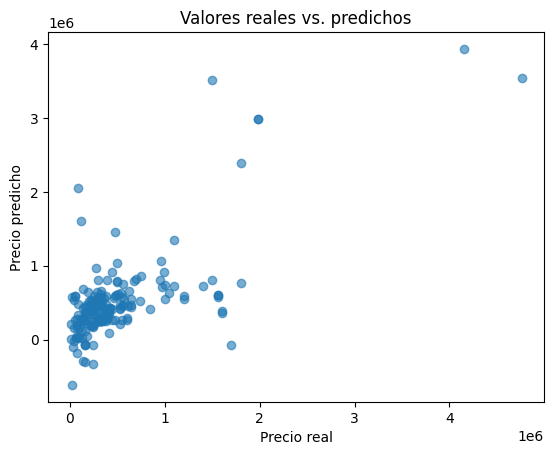

In [18]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Valores reales vs. predichos")
plt.show()

### Segunda Iteración

In [19]:
# Modelo sin varaiables no significativas
significant_vars = results[results["Significativo"] == "Sí"]["Variable"].tolist()
significant_vars.remove("Intercepto")  # Quitar el intercepto

In [20]:
X_sig_train = X_train[significant_vars]
X_sig_test = X_test[significant_vars]

In [21]:
model_sig = LinearRegression()
model_sig.fit(X_sig_train, y_train)

LinearRegression()

In [22]:
# Añadir constante (intercepto)
X_sig_train_ = np.column_stack((np.ones(X_sig_train.shape[0]), X_sig_train))

# Predicciones
y_sig_pred = model_sig.predict(X_sig_train)

# Residuos y sigma^2
n, k = X_sig_train_.shape
resid = y_train - y_sig_pred
sigma2 = np.sum(resid**2) / (n - k)

# Varianza-covarianza de los coeficientes
XtX_inv = np.linalg.inv(X_sig_train_.T @ X_sig_train_)
var_b = sigma2 * XtX_inv
se_b = np.sqrt(np.diag(var_b))  # errores estándar

# t-estadísticos y p-values
t_stats = model_sig.coef_.copy()
t_stats = np.insert(t_stats, 0, model_sig.intercept_)  # incluir el intercepto
t_values = t_stats / se_b
p_values = [2 * (1 - stats.t.cdf(np.abs(t), df=n - k)) for t in t_values]

# Mostrar resultados
results = pd.DataFrame({
    'Variable': ['Intercepto'] + list(X_sig_train.columns),
    'Coeficiente': t_stats,
    'p-value': p_values
})

In [23]:
# Agregar una columna que indique si es significativo (p < 0.05)
results["Significativo"] = results["p-value"].apply(
    lambda p: "Sí" if (p < 0.05) else "No" if not np.isnan(p) else "Indeterminado"
)

print(results)

               Variable   Coeficiente       p-value Significativo
0            Intercepto  8.229430e+06  6.470488e-06            Sí
1                  mts2  3.233704e+00  0.000000e+00            Sí
2              parqueos  4.640476e+04  2.095709e-08            Sí
3                 banos  9.540638e+04  3.459996e-07            Sí
4     CANT_SUPERMERCADO  1.694499e+04  5.921379e-03            Sí
5  hogares_techo_lamina  4.940231e+05  1.315749e-01            No
6       miembros_ph_avg -7.608320e+05  2.171578e-02            Sí
7      cnt_habit_ph_med -1.798124e+06  8.881784e-16            Sí
8              zona_avg -3.525567e-01  5.465594e-02            No


In [24]:
y_sig_pred = model_sig.predict(X_sig_test)

mae = mean_absolute_error(y_test, y_sig_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_sig_pred))
r2 = r2_score(y_test, y_sig_pred)

print("Resultados del modelo:")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

Resultados del modelo:
MAE  = 267627.15
RMSE = 451085.68
R²   = 0.411


## Tercera Iteración

In [25]:
# Modelo sin varaiables no significativas
significant_vars = results[results["Significativo"] == "Sí"]["Variable"].tolist()
significant_vars.remove("Intercepto")  # Quitar el intercepto

In [26]:
X_sig_train3 = X_train[significant_vars]
X_sig_test3 = X_test[significant_vars]

In [27]:
model_sig3 = LinearRegression()
model_sig3.fit(X_sig_train3, y_train)

LinearRegression()

In [28]:
# Añadir constante (intercepto)
X_sig_train_ = np.column_stack((np.ones(X_sig_train3.shape[0]), X_sig_train3))

# Predicciones
y_sig_pred = model_sig3.predict(X_sig_train3)

# Residuos y sigma^2
n, k = X_sig_train_.shape
resid = y_train - y_sig_pred
sigma2 = np.sum(resid**2) / (n - k)

# Varianza-covarianza de los coeficientes
XtX_inv = np.linalg.inv(X_sig_train_.T @ X_sig_train_)
var_b = sigma2 * XtX_inv
se_b = np.sqrt(np.diag(var_b))  # errores estándar

# t-estadísticos y p-values
t_stats = model_sig3.coef_.copy()
t_stats = np.insert(t_stats, 0, model_sig3.intercept_)  # incluir el intercepto
t_values = t_stats / se_b
p_values = [2 * (1 - stats.t.cdf(np.abs(t), df=n - k)) for t in t_values]

# Mostrar resultados
results = pd.DataFrame({
    'Variable': ['Intercepto'] + list(X_sig_train3.columns),
    'Coeficiente': t_stats,
    'p-value': p_values
})

In [29]:
# Agregar una columna que indique si es significativo (p < 0.05)
results["Significativo"] = results["p-value"].apply(
    lambda p: "Sí" if (p < 0.05) else "No" if not np.isnan(p) else "Indeterminado"
)

print(results)

            Variable   Coeficiente       p-value Significativo
0         Intercepto  5.497556e+06  1.554809e-05            Sí
1               mts2  3.173331e+00  0.000000e+00            Sí
2           parqueos  4.522478e+04  4.342831e-08            Sí
3              banos  9.840379e+04  1.382094e-07            Sí
4  CANT_SUPERMERCADO  1.060003e+04  4.699731e-02            Sí
5    miembros_ph_avg -3.552988e+05  1.806397e-01            No
6   cnt_habit_ph_med -1.395729e+06  0.000000e+00            Sí


In [33]:
y_sig_pred = model_sig3.predict(X_sig_train3)



metricas(y_train, y_sig_pred)


{'RMSE': 770511.5046116557,
 'MAPE': 1.781377234501809,
 'R2': 0.5434376777042309,
 'Mediana_ErrorAbs': np.float64(0.40366317392291173),
 'Pct_Error<0.3': np.float64(0.35528596187175043)}

In [30]:
y_sig_pred = model_sig3.predict(X_sig_test3)

mae = mean_absolute_error(y_test, y_sig_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_sig_pred))
r2 = r2_score(y_test, y_sig_pred)

print("Resultados del modelo:")
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

Resultados del modelo:
MAE  = 271437.34
RMSE = 455203.98
R²   = 0.400
